# A atenção de Bahdanau

**Atenção de Bahdanau:** simular um tradutor que está tentando decidir em qual palavra da frase de entrada focar.

**O Cenário:**

 - Query ($q$): O estado atual do decodificador (o que a rede está "pensando" agora).
 - Keys ($K$): As palavras da frase de entrada.
 - Values ($V$): O significado dessas palavras (no exemplo de Bahdanau, $K = V$).

In [ ]:
import numpy as np

In [ ]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x))

**1. Definições Iniciais**

- Vamos fingir que temos uma frase de 3 palavras (m=3)
- Cada palavra/estado é um vetor de tamanho 2 para facilitar a conta

In [ ]:
query = np.array([10, 0])          # O que eu procuro agora
keys = np.array([
    [10, 2],   # Palavra 1 (Muito parecida com a query)
    [1, 5],    # Palavra 2 (Diferente)
    [0, -1]    # Palavra 3 (Muito diferente)
])
values = keys  # keys e values são o mesmo vetor

print(f"--- PASSO 1: Query (Alvo) ---\n{query}")
print(f"\n--- PASSO 2: Keys (Candidatos) ---\n{keys}")

--- PASSO 1: Query (Alvo) ---
[10  0]

--- PASSO 2: Keys (Candidatos) ---
[[10  2]
 [ 1  5]
 [ 0 -1]]


**2. Cálculo do Score (Função de Alinhamento 'a')**

- Aqui usamos o produto escalar (dot product) para ver a similaridade
- a(q, ki) = q · ki

In [ ]:
scores = np.dot(keys, query)
print(f"\n--- PASSO 3: Scores (Similaridade Bruta) ---\n{scores}")


--- PASSO 3: Scores (Similaridade Bruta) ---
[100  10   0]


**3. Cálculo dos Pesos de Atenção (Alpha)**

- Aplicamos o Softmax para transformar scores em probabilidades (soma = 1)
- alpha = softmax(scores)

In [ ]:
weights = softmax(scores)
print(f"\n--- PASSO 4: Pesos Alpha (Atenção %) ---\n{weights}")


--- PASSO 4: Pesos Alpha (Atenção %) ---
[1.00000000e+00 8.19401262e-40 3.72007598e-44]


**4. Cálculo do Context Vector (Saída da Atenção)**

- É a soma ponderada: soma(alpha_i * v_i)

In [ ]:
context_vector = np.zeros(2)
for i in range(len(weights)):
    context_vector += weights[i] * values[i]

In [ ]:
print(f"\n--- PASSO 5: Vetor de Contexto Final ---\n{context_vector}")
print("\nNota: O vetor final ficou muito próximo da Palavra 1 porque a atenção focou nela!")


--- PASSO 5: Vetor de Contexto Final ---
[10.  2.]

Nota: O vetor final ficou muito próximo da Palavra 1 porque a atenção focou nela!


**O que aconteceu?**

**- Similaridade:** O código calculou o quão próxima a query está de cada key. Como a primeira linha de keys [10, 2] é muito parecida com a query [10, 0], ela ganhou o maior score.

**- Distribuição:** O softmax transformou esses scores em porcentagens. Você verá que o primeiro peso será algo como 0.99... (99% de atenção).

**- Foco:** O resultado final (Vetor de Contexto) é basicamente a "Palavra 1", mas levemente influenciada pelas outras.

**Mapa de Calor (Heatmap)** para visualização da atenção

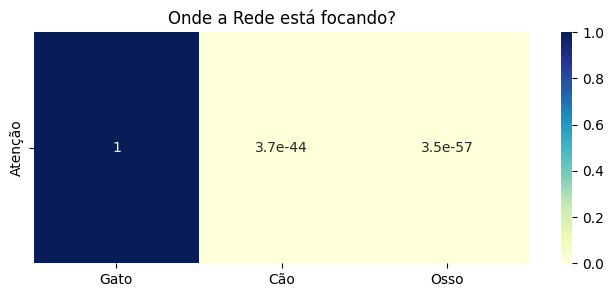

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x))

# Dados do exemplo anterior
palavras_entrada = ["Gato", "Cão", "Osso"]
query = np.array([10, 0])
keys = np.array([
    [11, 1],   # Gato (Alta similaridade)
    [1, 8],    # Cão  (Baixa)
    [-2, -2]   # Osso (Nula)
])

# Cálculo dos scores e pesos
scores = np.dot(keys, query)
weights = softmax(scores).reshape(1, -1) # Reshape para o heatmap (1 linha, 3 colunas)

# Plotagem
plt.figure(figsize=(8, 3))
sns.heatmap(weights, annot=True, xticklabels=palavras_entrada, yticklabels=["Atenção"],
            cmap="YlGnBu", cbar=True)

plt.title("Onde a Rede está focando?")
plt.show()

# Implementação simples com LSTM

Mecanismo de atenção simplificado

In [ ]:
import torch
import torch.nn.functional as F

--- 1. CONFIGURAÇÃO INICIAL ---

- Frase: "Eu amo IA" -> [0, 1, 2]

In [ ]:
input_indices = torch.tensor([[0, 1, 2]])
print(input_indices)
vocab_size = 10
embed_dim = 4   # Cada palavra vira um vetor de 4 números
hidden_dim = 8  # A memória da LSTM tem tamanho 8

tensor([[0, 1, 2]])


In [ ]:
# Pesos (Simulando o que a rede aprenderia)

# tabela (matriz) onde cada linha corresponde a uma palavra do vocabulário.
embedding = torch.nn.Embedding(vocab_size, embed_dim)

# recebe a sequência de palavras e cospe uma sequência de "estados ocultos" (h_t).
lstm = torch.nn.LSTM(embed_dim, hidden_dim, batch_first=True)

# Camada para o score. processar todos os h_t da frase. No final, você terá uma lista de "notas".
# Depois que você passar essas notas pelo Softmax, elas viram os pesos de atenção (ex: 0.8 para "Amo", 0.1 para "o", 0.1 para "filme").
attn_weights_layer = torch.nn.Linear(hidden_dim, 1)

print(embedding)

print(attn_weights_layer)

Embedding(10, 4)
Linear(in_features=8, out_features=1, bias=True)


--- 2. PASSO A PASSO (O FLUXO) ---

In [ ]:
# A. Embedding: Transforma índices em vetores densos
# Shape: [1, 3] -> [1, 3, 4] (1 frase, 3 palavras, vetor de 4)
embedded = embedding(input_indices)
print(embedded)

tensor([[[-0.1635, -0.4793,  0.3180, -0.6778],
         [ 0.5174,  1.8086,  1.5767, -0.4720],
         [-0.2200,  1.8941, -0.3956,  0.0529]]], grad_fn=<EmbeddingBackward0>)


In [ ]:
# B. LSTM: Processa a sequência
# h_states contém o h_t de CADA palavra. Shape: [1, 3, 8]
h_states, _ = lstm(embedded)
print(h_states)

tensor([[[-0.1362, -0.1691, -0.0592,  0.0072, -0.0438, -0.0388, -0.0586,
           0.0840],
         [-0.3026, -0.4710, -0.2005, -0.1274,  0.0862, -0.2911, -0.1671,
           0.1551],
         [-0.3475, -0.4291, -0.0829, -0.1270,  0.1462, -0.1948, -0.2732,
           0.1406]]], grad_fn=<TransposeBackward0>)


In [ ]:
# C. ATENÇÃO: Calculando a importância de cada h_t
# Passamos todos os h_t pela camada linear para ter um 'score'
scores = attn_weights_layer(h_states) # Shape: [1, 3, 1]
print(scores)

tensor([[[-0.3326],
         [-0.3090],
         [-0.3562]]], grad_fn=<ViewBackward0>)


In [ ]:
# D. SOFTMAX: Transforma scores em probabilidades (pesos que somam 1)
alphas = F.softmax(scores, dim=1) # Shape: [1, 3, 1]
print("Pesos de Atenção (Alphas):\n", alphas.detach().numpy().flatten())

Pesos de Atenção (Alphas):
 [0.33327708 0.34121433 0.32550862]


In [ ]:
# E. VETOR DE CONTEXTO: Multiplica cada h_t pelo seu peso e soma tudo
# É aqui que a "mágica" acontece: as palavras importantes brilham mais
context_vector = torch.sum(alphas * h_states, dim=1) # Shape: [1, 8]

In [ ]:
print("\nVetor de Contexto Final (Resumo da frase):\n", context_vector.detach().numpy())


Vetor de Contexto Final (Resumo da frase):
 [[-0.26176816 -0.35673243 -0.11514302 -0.0824213   0.06240778 -0.17563282
  -0.16544855  0.1266696 ]]


In [ ]:
alphas[0,0]*h_states[0,0] + alphas[0,1]*h_states[0,1] + alphas[0,2]*h_states[0,2]

tensor([-0.2618, -0.3567, -0.1151, -0.0824,  0.0624, -0.1756, -0.1654,  0.1267],
       grad_fn=<AddBackward0>)

**Código de Treinamento (Passo a Passo)**

Neste exemplo, vamos forçar a rede a aprender uma regra boba:
- Se a frase tiver a palavra 'amo', a resposta é 1 (Positivo).
- Se não tiver, é 0 (Negativo).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
# 1. Configuração e Dados (Onde 1 = 'amo')
# Frase 1: "eu amo ia" -> Positivo (1) | Frase 2: "eu odeio ia" -> Negativo (0)
# Dados de treino
# dados_treino = [
#     (torch.tensor([[0, 1, 2]]), torch.tensor([1])), # "eu amo ia" -> Positivo
#     (torch.tensor([[0, 3, 2]]), torch.tensor([0])), # "eu odeio ia" -> Negativo (IA está aqui, mas o peso deve cair)
#     (torch.tensor([[0, 1, 4]]), torch.tensor([1])),  # "eu amo café" -> Positivo (Foco no amo)
#     (torch.tensor([[0, 1, 5]]), torch.tensor([0]))   # "eu odeio exercicio" -> Negativo
# ]

# 1. Dados Estratégicos (Dando "nós" na cabeça da rede)
# Se ela focar só na última palavra (2 ou 4), ela vai errar,
# pois a última palavra aparece em ambos os sentimentos.
# Vocabulário: 0:eu, 1:amo, 2:ia, 3:odeio, 4:ia (ruído)
dados_treino = [
    (torch.tensor([[0, 1, 2]]), torch.tensor([1])), # eu AMO ia -> Positivo
    (torch.tensor([[0, 3, 2]]), torch.tensor([0])), # eu ODEIO ia -> Negativo
    (torch.tensor([[0, 1, 4]]), torch.tensor([1])), # eu AMO tecnologia -> Positivo
    (torch.tensor([[0, 3, 4]]), torch.tensor([0]))  # eu ODEIO tecnologia -> Negativo
]

# 1. DADOS DE "ESTRESSE" (O final não serve para nada)
# 1=amo (Positivo), 3=odeio (Negativo). O resto é ruído.
# dados_treino = [
#     (torch.tensor([[0, 1, 2, 5, 6]]), torch.tensor([1])), # eu AMO ia ... blabla
#     (torch.tensor([[0, 3, 5, 5, 6]]), torch.tensor([0])), # eu ODEIO nadar ... blabla
#     (torch.tensor([[0, 1, 4, 7, 8]]), torch.tensor([1])), # eu AMO tecnologia ...
#     (torch.tensor([[0, 3, 6, 7, 8]]), torch.tensor([0]))  # eu ODEIO correr ...
# ]

In [ ]:
# 2. Inicialização das Camadas (Como antes)
#vocab_size, embed_dim, hidden_dim = 10, 4, 8
vocab_size, embed_dim, hidden_dim = 15, 10, 20 # Aumenta a capacidade
embedding = nn.Embedding(vocab_size, embed_dim)
lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
attn_layer = nn.Linear(hidden_dim, 1)
saida_final = nn.Linear(hidden_dim, 2) # Camada para classificar 0 ou 1

In [ ]:
# 3. Otimizador e Função de Erro
optimizer = optim.Adam(list(embedding.parameters()) + list(lstm.parameters()) +
                       list(attn_layer.parameters()) + list(saida_final.parameters()), lr=0.05)
criterion = nn.CrossEntropyLoss()

In [ ]:
# 4. Loop de Treinamento (Rodando 50 vezes para aprender)
print("Treinando...")
for epoch in range(400):
    for x, y in dados_treino:
        optimizer.zero_grad() # Limpa o erro anterior

        # Forward (O fluxo que já conhecemos)
        emb = embedding(x)
        h_states, _ = lstm(emb)
        scores = attn_layer(h_states)
        alphas = F.softmax(scores, dim=1)
        context = torch.sum(alphas * h_states, dim=1)
        predicao = saida_final(context)

        # Cálculo do Erro e Ajuste
        loss = criterion(predicao, y)
        loss.backward()  # <--- Aqui a Atenção descobre quem é importante!
        optimizer.step()

Treinando...


In [ ]:
# 5. TESTE FINAL: Vamos ver onde a atenção está focando agora?
frase_teste = torch.tensor([[0, 1, 2]]) # "eu amo ia"
emb = embedding(frase_teste)
h_states, _ = lstm(emb)
alphas_finais = F.softmax(attn_layer(h_states), dim=1)

In [ ]:
print("\nPesos de Atenção após o treino:")
print(f"Palavra 1 (eu):  {alphas_finais[0,0,0]:.4f}")
print(f"Palavra 2 (amo): {alphas_finais[0,1,0]:.4f}  <-- FOCO AQUI!")
print(f"Palavra 3 (ia):  {alphas_finais[0,2,0]:.4f}")


Pesos de Atenção após o treino:
Palavra 1 (eu):  0.0577
Palavra 2 (amo): 0.4537  <-- FOCO AQUI!
Palavra 3 (ia):  0.4887


In [ ]:
# 5. TESTE FINAL: Vamos ver onde a atenção está focando agora?
frase_teste = torch.tensor([[0, 3, 2]]) # "eu odeio ia"
emb = embedding(frase_teste)
h_states, _ = lstm(emb)
alphas_finais = F.softmax(attn_layer(h_states), dim=1)

print("\nPesos de Atenção após o treino:")
print(f"Palavra 1 (eu):  {alphas_finais[0,0,0]:.4f}")
print(f"Palavra 2 (odeio): {alphas_finais[0,1,0]:.4f}  <-- FOCO AQUI!")
print(f"Palavra 3 (ia):  {alphas_finais[0,2,0]:.4f}")


Pesos de Atenção após o treino:
Palavra 1 (eu):  0.0002
Palavra 2 (odeio): 0.9988  <-- FOCO AQUI!
Palavra 3 (ia):  0.0010
